First i will import all libraiery for work and EDA 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [9]:
df=pd.read_csv('C:\\Users\\pintu\\OneDrive\\Pictures\\Documents\\seven_eleven.csv')

In [11]:
df.head(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,5/2/2010,1643690.90,0,42.31,2.572,211.1,8.106
1,1,12/2/2010,1641957.44,1,38.51,2.548,211.2,8.106
2,1,19/02/2010,1611968.17,0,39.93,2.514,211.3,8.106
3,1,26/02/2010,1409727.59,0,46.63,2.561,211.3,8.106
4,1,5/3/2010,1554806.68,0,46.50,2.625,211.4,8.106


In [20]:
df.shape

(6435, 8)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


In [22]:
df.isnull().sum()   

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [23]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578959,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.357125,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.100000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.700000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.600000,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.700000,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.200000,14.313000


In [10]:
df["Date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [12]:
df["Date"] =pd.to_datetime(df["Date"], format="%d/%m/%Y")

In [8]:
df["Date"].dtype

dtype('<M8[us]')

In [9]:
df.head(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.1,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.2,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.3,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.3,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.4,8.106


In [31]:
df.duplicated().sum()

np.int64(0)

# Let's  do EDA 

In [ ]:
# Q1: How do total weekly sales change year over year?

In [13]:
df["Year"]= df["Date"].dt.year

In [63]:
Sales_year =df.groupby("Year", as_index=False)["Weekly_Sales"].sum().round(2)

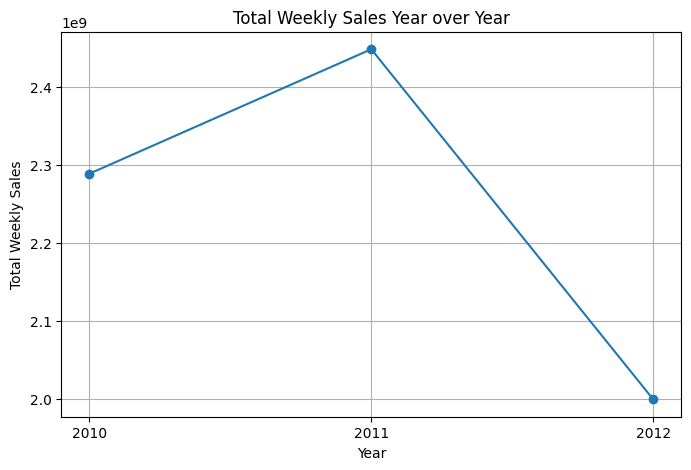

In [68]:
plt.figure(figsize=(8,5))

plt.plot(
    Sales_year["Year"],
    Sales_year["Weekly_Sales"],
    marker="o"
)
plt.xticks(Sales_year["Year"].astype(int))
plt.title("Total Weekly Sales Year over Year")
plt.xlabel("Year")
plt.ylabel("Total Weekly Sales")

plt.grid(True)
plt.show()

In [ ]:
# Q2: What are the top 10 highest weekly sales records by store?

In [20]:
top_10_Store_wise_Sales = df.sort_values("Weekly_Sales", ascending=False).head(10)

top_10_Store_wise_Sales

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year
1905,14,2010-12-24,3818686.45,0,30.59,3.141,182.5,8.724,2010
2763,20,2010-12-24,3766687.43,0,25.17,3.141,204.6,7.484,2010
1333,10,2010-12-24,3749057.69,0,57.06,3.236,127.0,9.003,2010
527,4,2011-12-23,3676388.98,0,35.92,3.103,130.0,5.143,2011
1762,13,2010-12-24,3595903.20,0,34.90,2.846,127.0,7.795,2010
1814,13,2011-12-23,3556766.03,0,24.76,3.186,130.0,6.392,2011
2815,20,2011-12-23,3555371.03,0,40.19,3.389,212.2,7.082,2011
475,4,2010-12-24,3526713.39,0,43.21,2.887,127.0,7.127,2010
1385,10,2011-12-23,3487986.89,0,48.36,3.541,130.0,7.874,2011
189,2,2010-12-24,3436007.68,0,49.97,2.886,211.1,8.163,2010


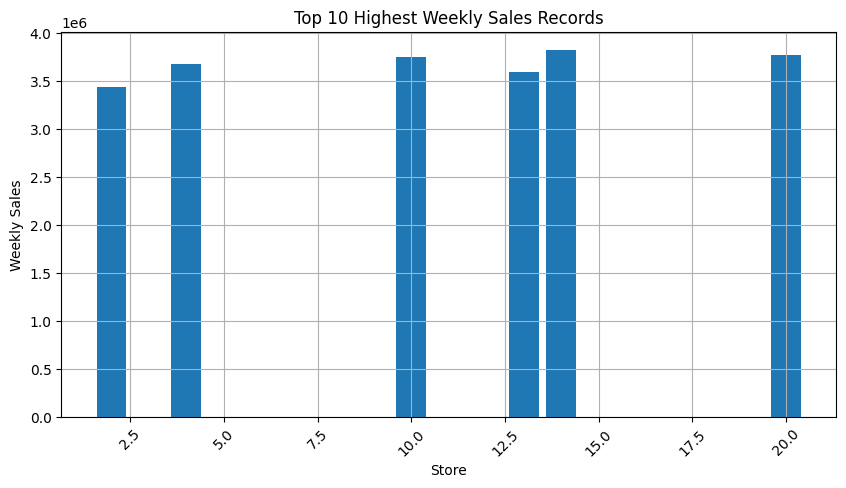

In [21]:
plt.figure(figsize=(10,5))

plt.bar(
    top_10_Store_wise_Sales["Store"],
    top_10_Store_wise_Sales["Weekly_Sales"]
)

plt.title("Top 10 Highest Weekly Sales Records")
plt.xlabel("Store")
plt.ylabel("Weekly Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
#  Q3:-  How does the unemployment rate change over time?

In [99]:
Year_by_Unemployment = df.groupby ("Year",as_index=False)["Unemployment"].mean()

Year_by_Unemployment

,Year,Unemployment
0,2010,8.492714
1,2011,8.082036
2,2012,7.347964


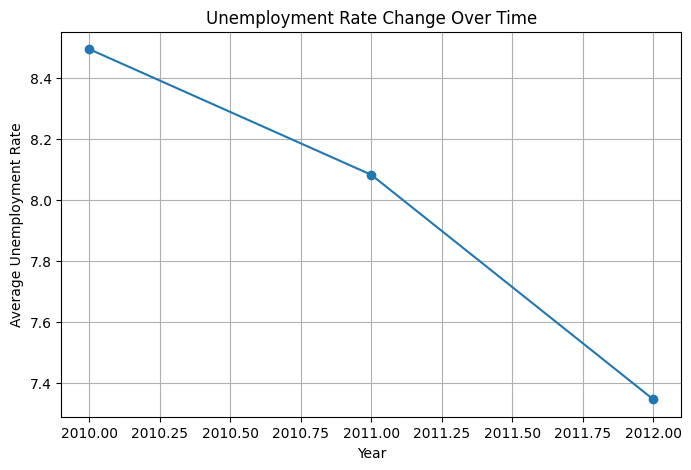

In [101]:
plt.figure(figsize=(8,5))

plt.plot(
    Year_by_Unemployment["Year"],
    Year_by_Unemployment["Unemployment"],
    marker="o"
)

plt.title("Unemployment Rate Change Over Time")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate")
plt.grid(True)
plt.show()

In [ ]:
# Q4 How does sales performance differ across stores?

In [22]:
stor_wise_Weeklysales= df.groupby("Store",as_index=False)["Weekly_Sales"].sum().sort_values("Weekly_Sales", ascending=False).round(2)
stor_wise_Weeklysales

,Store,Weekly_Sales
19,20,3.013978e+08
3,4,2.995440e+08
13,14,2.889999e+08
12,13,2.865177e+08
1,2,2.753824e+08
9,10,2.716177e+08
26,27,2.538559e+08
5,6,2.237561e+08
0,1,2.224028e+08
38,39,2.074455e+08


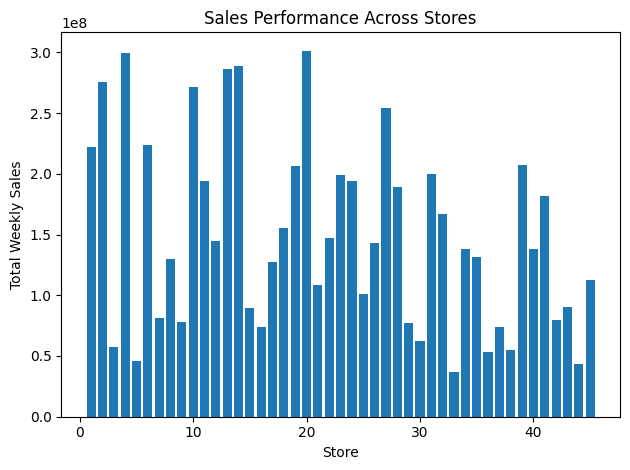

In [23]:
plt.Figure(figsize=(8,5))
plt.bar(
    stor_wise_Weeklysales["Store"],
    stor_wise_Weeklysales["Weekly_Sales"]
)

plt.title("Sales Performance Across Stores")
plt.xlabel("Store")
plt.ylabel("Total Weekly Sales")

plt.tight_layout()
plt.show()

In [ ]:
# Q5 How do weekly sales compare between holiday and non-holiday weeks?

In [8]:
holiday_flag_wise_weekly_sales = df.groupby("Holiday_Flag", as_index=False)["Weekly_Sales"].mean().round(2)

holiday_flag_wise_weekly_sales


,Holiday_Flag,Weekly_Sales
0,0,1041256.38
1,1,1122887.89


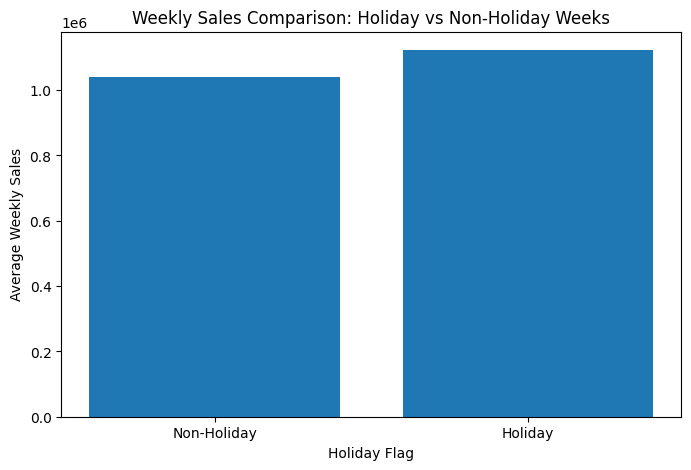

In [10]:
plt.figure(figsize=(8,5))
plt.bar(
    holiday_flag_wise_weekly_sales["Holiday_Flag"],
    holiday_flag_wise_weekly_sales["Weekly_Sales"]
)
plt.xticks([0, 1], ["Non-Holiday", "Holiday"])
plt.title("Weekly Sales Comparison: Holiday vs Non-Holiday Weeks")
plt.xlabel("Holiday Flag")
plt.ylabel("Average Weekly Sales")
plt.show()


In [ ]:
# Q6 How do weekly sales vary with temperature?

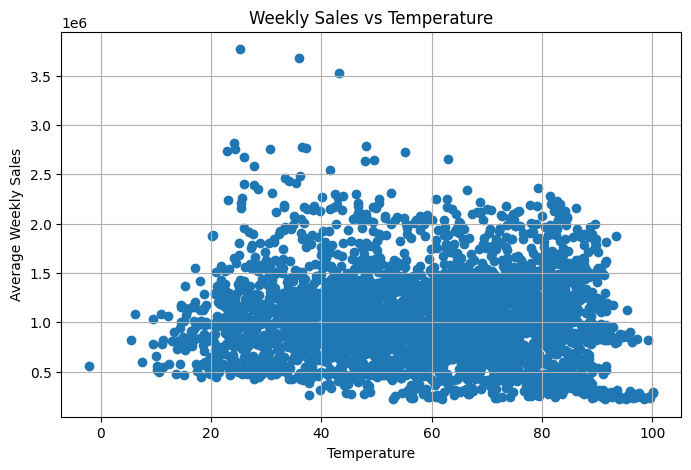

Correlation between Temperature and Weekly Sales: -0.06


In [17]:
# Step 1: Temperature-wise average weekly sales
Temperature_wise_weekly_sales = (
    df.groupby("Temperature", as_index=False)["Weekly_Sales"]
      .mean()
      .round(2)
)

# Step 2: View the result
Temperature_wise_weekly_sales.head(5)


# Step 3: Scatter plot
plt.figure(figsize=(8,5))

plt.scatter(
    Temperature_wise_weekly_sales["Temperature"],
    Temperature_wise_weekly_sales["Weekly_Sales"]
)

plt.title("Weekly Sales vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Average Weekly Sales")
plt.grid(True)
plt.show()


# Step 4: Correlation
temperature_sales_corr = df["Temperature"].corr(df["Weekly_Sales"])

print("Correlation between Temperature and Weekly Sales:",
      round(temperature_sales_corr, 2))

In [ ]:
# Q7 How do weekly sales vary with fuel prices?

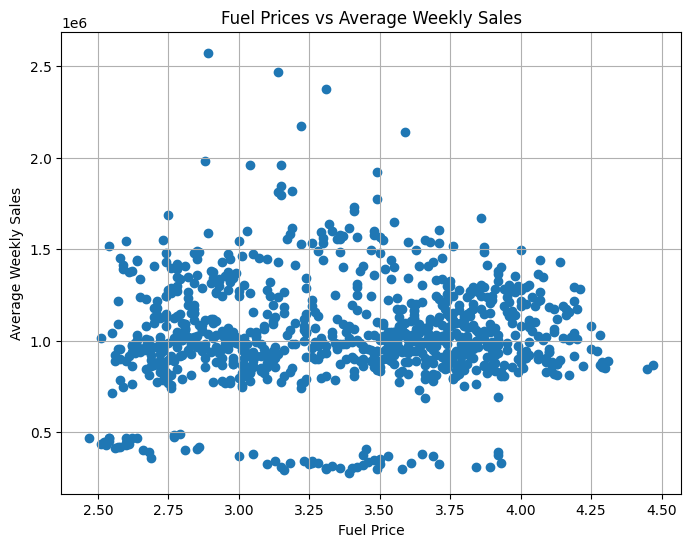

Correlation between Fuel Prices and Weekly Sales: 0.01


In [25]:
# Q7: How do weekly sales vary with fuel prices?

Fuel_prices_weekly_sales = (
    df.groupby("Fuel_Price", as_index=False)["Weekly_Sales"]
      .mean()
      .round(2)
)

Fuel_prices_weekly_sales

plt.figure(figsize=(8,6))

plt.scatter(
    Fuel_prices_weekly_sales["Fuel_Price"],
    Fuel_prices_weekly_sales["Weekly_Sales"]
)

plt.title("Fuel Prices vs Average Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Average Weekly Sales")
plt.grid(True)

plt.show()

fuel_sales_corr = df["Fuel_Price"].corr(df["Weekly_Sales"])

print(
    "Correlation between Fuel Prices and Weekly Sales:",
    round(fuel_sales_corr, 2)
)

In [ ]:
# Q8  How does fuel price change over time?

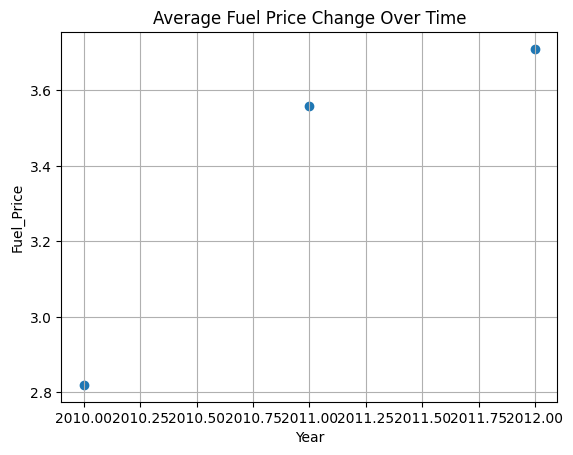

In [ ]:
Year_wise_Avg_Fuel_Price = df.groupby("Year",as_index=False)["Fuel_Price"].mean().round(2)

Year_wise_Avg_Fuel_Price


plt.figure(figsize=(8,6))
plt.scatter(
    
    Year_wise_Avg_Fuel_Price["Year"],
    Year_wise_Avg_Fuel_Price["Fuel_Price"]
    
)


plt.title("Average Fuel Price Change Over Time")
plt.xlabel('Year')
plt.ylabel("Fuel_Price")
plt.grid(True)

plt.show()






In [4]:
df 

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-05-02,1643690.90,0,42.31,2.572,211.1,8.106
1,1,2010-12-02,1641957.44,1,38.51,2.548,211.2,8.106
2,1,19/02/2010,1611968.17,0,39.93,2.514,211.3,8.106
3,1,26/02/2010,1409727.59,0,46.63,2.561,211.3,8.106
4,1,2010-05-03,1554806.68,0,46.50,2.625,211.4,8.106
...,...,...,...,...,...,...,...,...
6430,45,28/09/2012,713173.95,0,64.88,3.997,192.0,8.684
6431,45,2012-05-10,733455.07,0,64.89,3.985,192.2,8.667
6432,45,2012-12-10,734464.36,0,54.47,4.000,192.3,8.667
6433,45,19/10/2012,718125.53,0,56.47,3.969,192.3,8.667


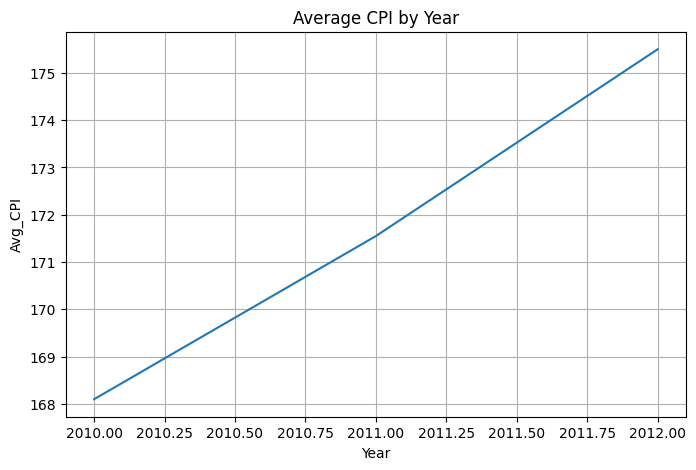

In [20]:
# Q9: How does the Consumer Price Index (CPI) change over time?

Years_wise_CPI = df.groupby("Year",as_index=False)["CPI"].mean().round(2)

plt.figure(figsize=(8,5))
plt.plot(
    Years_wise_CPI["Year"],
    Years_wise_CPI["CPI"]
)


plt.title("Average CPI by Year")
plt.xlabel("Year")
plt.ylabel("Avg_CPI")
plt.grid(True)

plt.show()

Correlation between CPI and Weekly Sales: -0.07


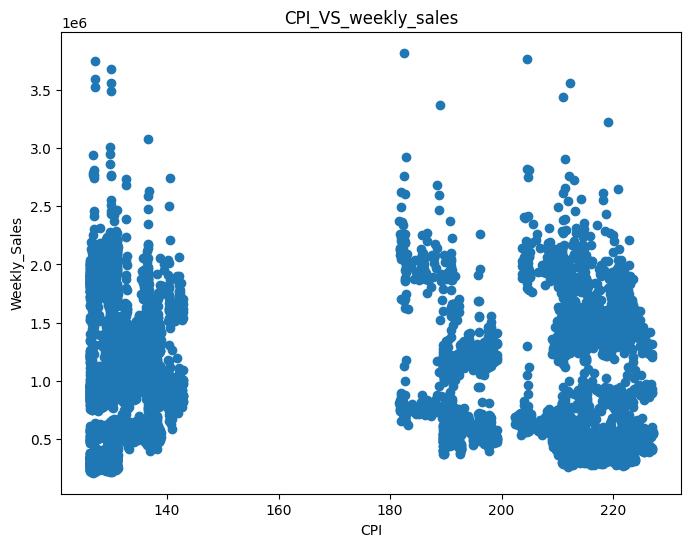

In [19]:
# Q10: How does the Consumer Price Index (CPI) relate to weekly sales?

correlation = df["CPI"].corr(df["Weekly_Sales"])

print("Correlation between CPI and Weekly Sales:", round(correlation, 2))

plt.figure(figsize=(8,6))


plt.scatter(df["CPI"],
           df["Weekly_Sales"]
)


plt.title("CPI_VS_weekly_sales") 
plt.xlabel("CPI")
plt.ylabel("Weekly_Sales")

plt.show()
